In [1]:
print("Hello, Data Analytics!")

Hello, Data Analytics!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail_sales.csv")

df.head()


ModuleNotFoundError: No module named 'seaborn'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail_sales.csv")

df.head()

EmptyDataError: No columns to parse from file

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail_sales.csv")

df.head()

EmptyDataError: No columns to parse from file

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail_sales.csv")

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,Cost of goods sold,Gross margin percentage,Gross income,Customer stratification rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [2]:
df.shape

(1000, 17)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Invoice ID                      1000 non-null   str    
 1   Branch                          1000 non-null   str    
 2   City                            1000 non-null   str    
 3   Customer type                   1000 non-null   str    
 4   Gender                          1000 non-null   str    
 5   Product line                    1000 non-null   str    
 6   Unit price                      1000 non-null   float64
 7   Quantity                        1000 non-null   int64  
 8   Tax 5%                          1000 non-null   float64
 9   Total                           1000 non-null   float64
 10  Date                            1000 non-null   str    
 11  Time                            1000 non-null   str    
 12  Payment                         1000 non-null 

In [4]:
df.isnull().sum()

Invoice ID                        0
Branch                            0
City                              0
Customer type                     0
Gender                            0
Product line                      0
Unit price                        0
Quantity                          0
Tax 5%                            0
Total                             0
Date                              0
Time                              0
Payment                           0
Cost of goods sold                0
Gross margin percentage           0
Gross income                      0
Customer stratification rating    0
dtype: int64

In [5]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,Cost of goods sold,Gross margin percentage,Gross income,Customer stratification rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [6]:
df["Total"].mean()

np.float64(322.966749)

In [7]:
df["Total"].median()

np.float64(253.848)

In [8]:
df["Total"].mode()[0]

np.float64(87.234)

In [9]:
df["Total"].std()


np.float64(245.88533510097187)

In [11]:
df["Date"] = pd.to_datetime(df["Date"])

In [12]:
df["Month"] = df["Date"].dt.to_period("M")

In [13]:
monthly_sales = df.groupby("Month")["Total"].sum()

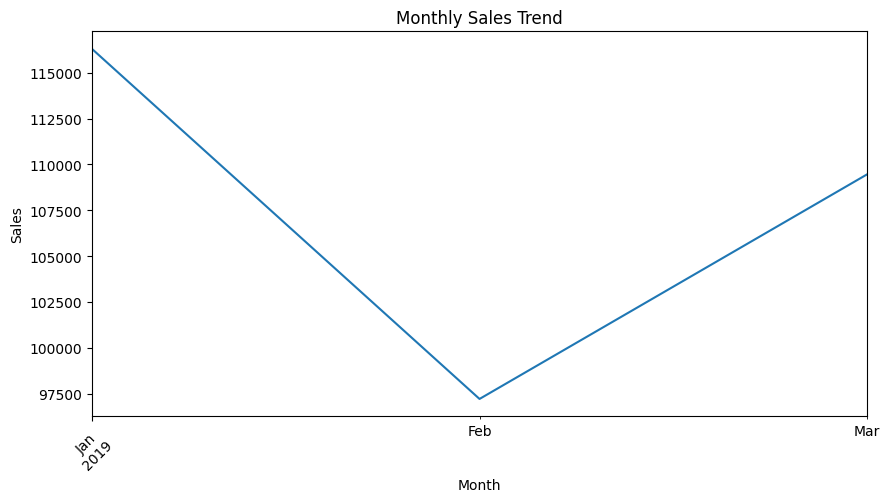

In [14]:
monthly_sales.plot(kind="line", figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [15]:
df["Gender"].value_counts()

Gender
Female    501
Male      499
Name: count, dtype: int64

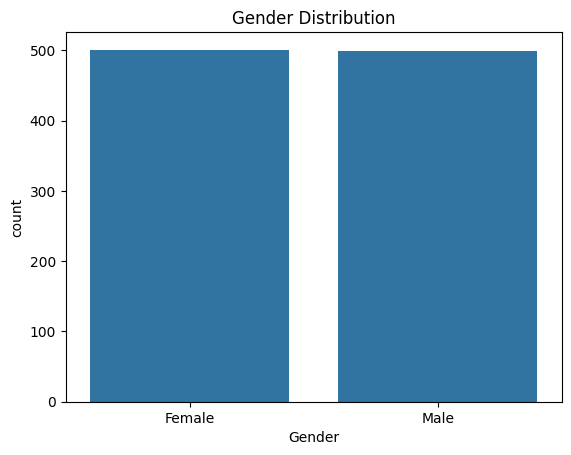

In [16]:
sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")
plt.show()

In [17]:
top_products = df.groupby("Product line")["Quantity"].sum().sort_values(ascending=False).head(10)

top_products

Product line
Electronic accessories    971
Food and beverages        952
Sports and travel         920
Home and lifestyle        911
Fashion accessories       902
Health and beauty         854
Name: Quantity, dtype: int64

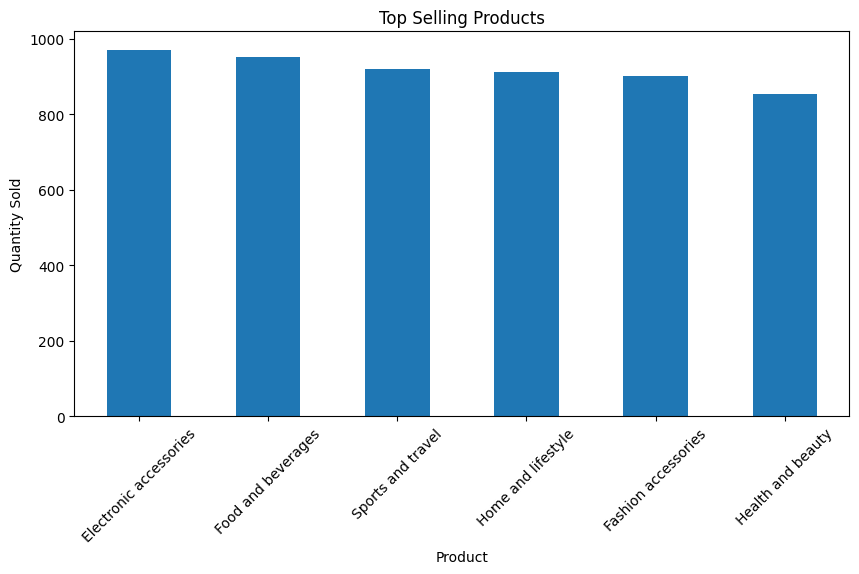

In [18]:
top_products.plot(kind="bar", figsize=(10,5))

plt.title("Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

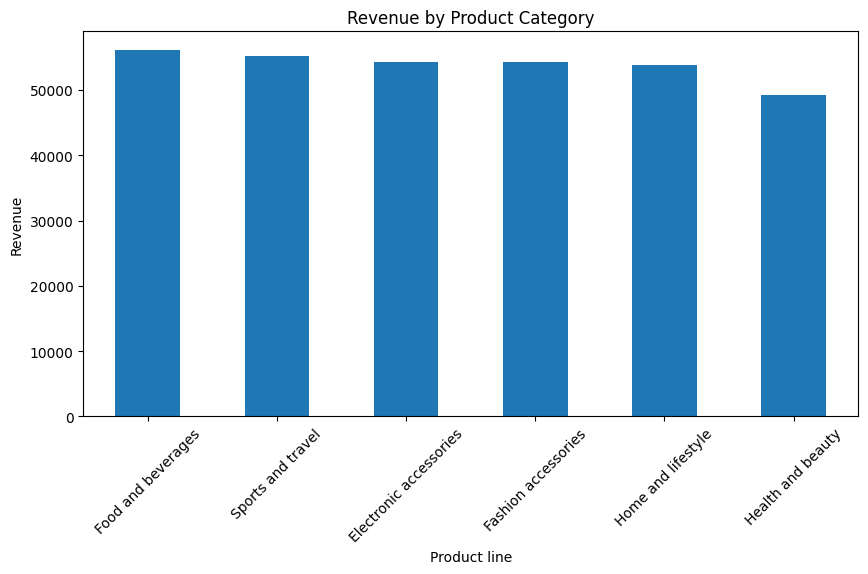

In [19]:
category_revenue = df.groupby("Product line")["Total"].sum().sort_values(ascending=False)

category_revenue.plot(kind="bar", figsize=(10,5))

plt.title("Revenue by Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

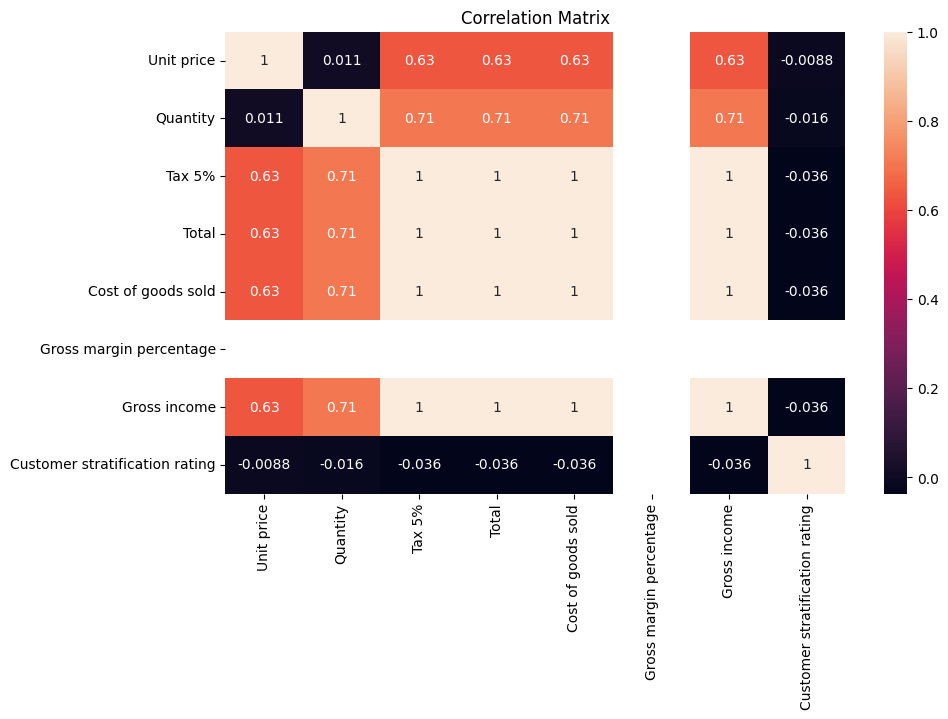

In [20]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True)

plt.title("Correlation Matrix")
plt.show()

## Business Recommendations

Based on the exploratory data analysis, the following recommendations can be made:

1. **Focus on high-performing product categories:**  
   The business should maintain sufficient inventory and promote products from the categories that generate the highest sales and revenue.

2. **Improve marketing during low-sales periods:**  
   Monthly sales trends should be monitored to identify low-performing months. Special discounts, promotional campaigns, and targeted offers can be introduced during these periods.

3. **Target customers based on demographics:**  
   Customer demographic analysis can be used to design targeted marketing campaigns based on gender and age-group purchasing patterns.

4. **Increase sales through cross-selling:**  
   Products that are frequently purchased can be promoted together through bundle offers and cross-selling strategies.

5. **Monitor transaction performance:**  
   The relationship between quantity, unit price, and total sales should be regularly monitored to identify opportunities for increasing transaction value.